<a href="https://colab.research.google.com/github/dayananathalih-prog/EstadisticaVerano2026/blob/main/GymMembers/GYMMEMBERSu2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import pandas as pd
df = pd.read_csv("https://raw.githubusercontent.com/dayananathalih-prog/EstadisticaVerano2026/refs/heads/main/GymMembers/gym_members_exercise_tracking%202.csv")
df


,Edad,Genero,Peso (kg),Altura (m),BPM_Max,Promedio_BPM,Reposo_BPM,Duracion_Sesionhrs,Calorias_Quemadas,Tipo_Entrenamiento,Porcentaje_Grasa,Consumo_Agua (litros),Frecuencia_Entrenamiento (dias/semanas),Nivel_Experiencia,IMC
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Edad                                     973 non-null    int64  
 1   Genero                                   973 non-null    object 
 2   Peso (kg)                                973 non-null    float64
 3   Altura (m)                               973 non-null    float64
 4   BPM_Max                                  973 non-null    int64  
 5   Promedio_BPM                             973 non-null    int64  
 6   Reposo_BPM                               973 non-null    int64  
 7   Duracion_Sesionhrs                       973 non-null    float64
 8   Calorias_Quemadas                        973 non-null    float64
 9   Tipo_Entrenamiento                       973 non-null    object 
 10  Porcentaje_Grasa                         973 non-n

In [66]:
# Variables enteras
enteras = df.select_dtypes(include=['int64']).columns
print("Variables enteras:")
print(enteras)

# Variables categóricas
categoricas = df.select_dtypes(include=['object']).columns
print("Variables categóricas:")
print(categoricas)

# Variables decimales
decimales = df.select_dtypes(include=['float64']).columns
print("Variables decimales:")
print(decimales)

Variables enteras:
Index(['Edad', 'BPM_Max', 'Promedio_BPM', 'Reposo_BPM',
       'Frecuencia_Entrenamiento (dias/semanas)', 'Nivel_Experiencia'],
      dtype='object')
Variables categóricas:
Index(['Genero', 'Tipo_Entrenamiento'], dtype='object')
Variables decimales:
Index(['Peso (kg)', 'Altura (m)', 'Duracion_Sesionhrs', 'Calorias_Quemadas',
       'Porcentaje_Grasa', 'Consumo_Agua (litros)', 'IMC'],
      dtype='object')


In [67]:
df.dropna(inplace=True)

+ `Edad` es del tipo entero.
+ `PP_Max`es del tipo entero.
+ `PPm_promedio` es del tipo entero.
+ `Reposo` es del tipo entero.
+ `Frecuencia_entrenamiento (days/week)` es del tipo entero.
+ `Nivel_experiencia` es del tipo entero.



+ `Genero` es del tipo categorica
+ `Tipo_entrenamiento`es del tipo categorica

+ `Peso` es del tipo numerico.
+ `Altura`es del tipo numerico.
+ `Duracionsesion_horas` es del tipo numerico.
+ `calorias_quemadas` es del tipo numerico.
+ `Porcentaje_grasa` es del tipo numerico.
+ `Consumo_agua` es del tipo numerico.
+ `IMC` es del tipo numerico.

   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1   group2  meandiff p-adj   lower    upper   reject
----------------------------------------------------------
  Cardio     HIIT  41.2917 0.3523 -23.1974 105.7809  False
  Cardio Strength  26.1839 0.6973 -35.7784  88.1463  False
  Cardio     Yoga  18.6746 0.8721 -44.5002  81.8494  False
    HIIT Strength -15.1078 0.9306 -79.4226  49.2071  False
    HIIT     Yoga -22.6171 0.8107 -88.1009  42.8666  False
Strength     Yoga  -7.5094   0.99 -70.5062  55.4875  False
----------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

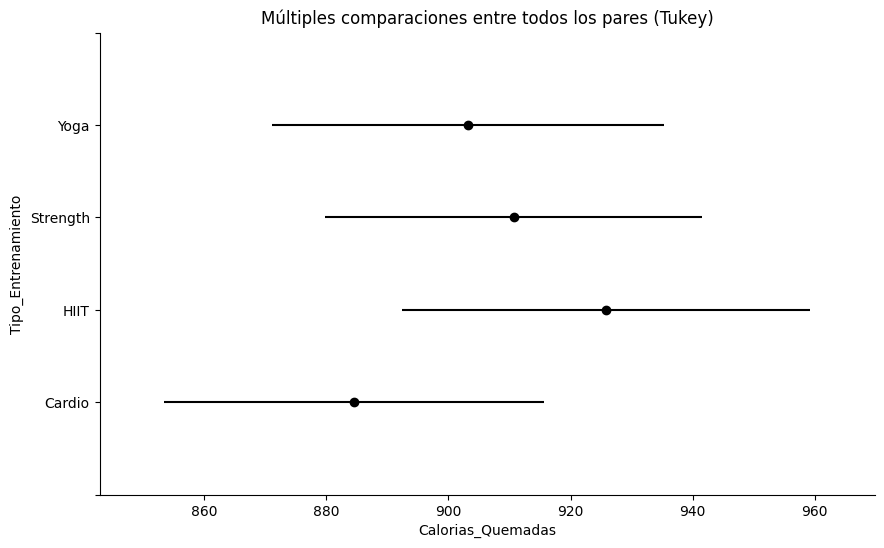

In [68]:
# Prueba pos-hoc, porque se debe hacer después de ANOVA
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(
    endog=df['Calorias_Quemadas'], # Variable de respuesta
    groups=df['Tipo_Entrenamiento'],  # Variable categorica nominal
    alpha=nivel_de_significancia) # nivel de significancia

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Tipo_Entrenamiento", xlabel="Calorias_Quemadas")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [69]:
df["Tipo_Entrenamiento"] = df["Tipo_Entrenamiento"].map({
    "Cardio": 0,
    "Yoga": 1,
    "Strength": 2,
    "HIIT": 3
})

df

,Edad,Genero,Peso (kg),Altura (m),BPM_Max,Promedio_BPM,Reposo_BPM,Duracion_Sesionhrs,Calorias_Quemadas,Tipo_Entrenamiento,Porcentaje_Grasa,Consumo_Agua (litros),Frecuencia_Entrenamiento (dias/semanas),Nivel_Experiencia,IMC
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,1,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,3,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,0,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,2,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,2,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,2,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,2,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,0,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,3,28.2,2.1,3,2,37.74


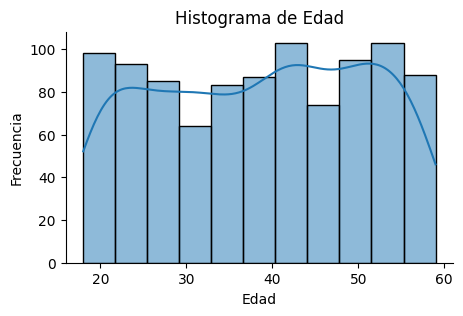

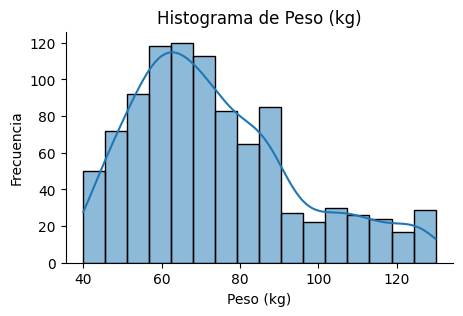

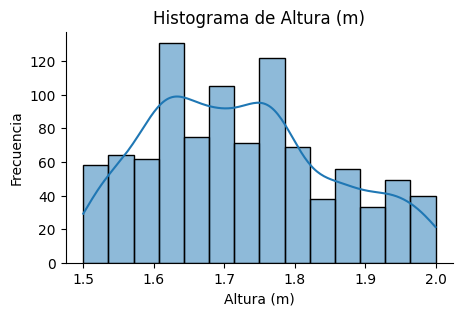

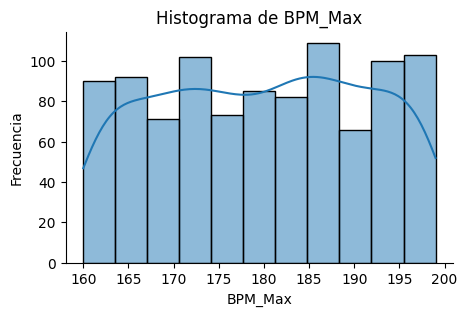

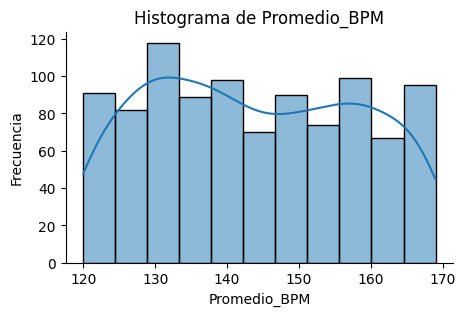

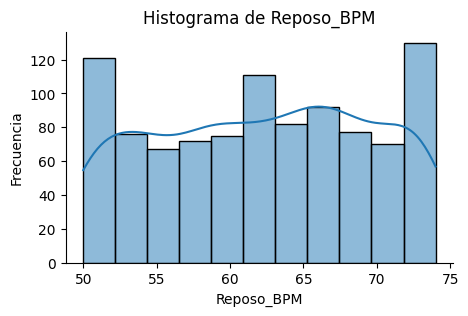

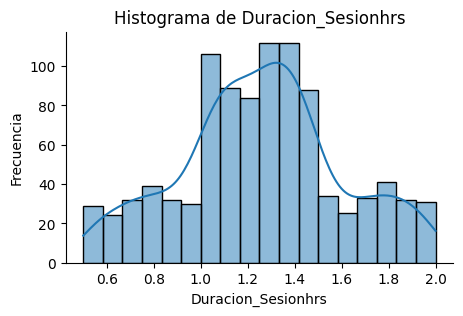

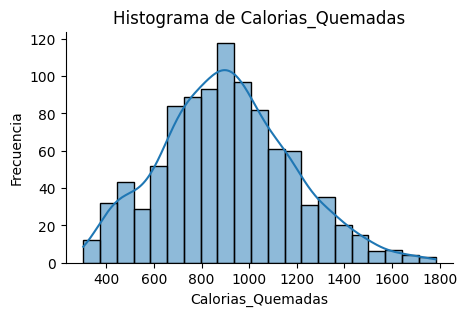

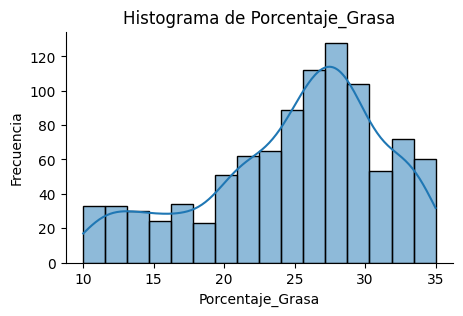

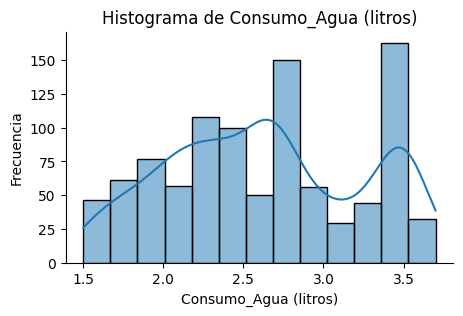

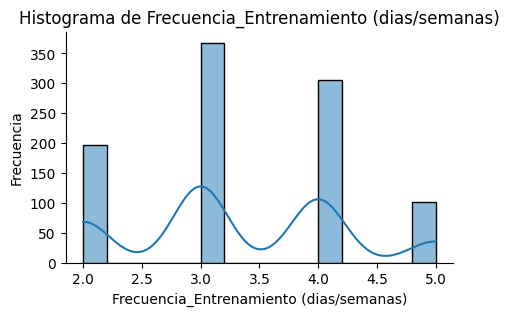

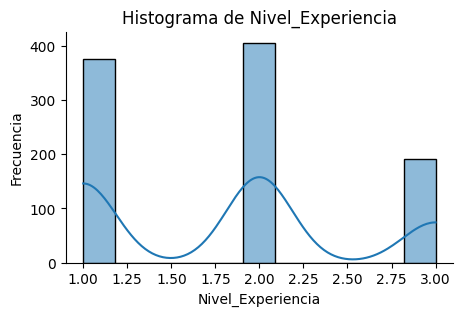

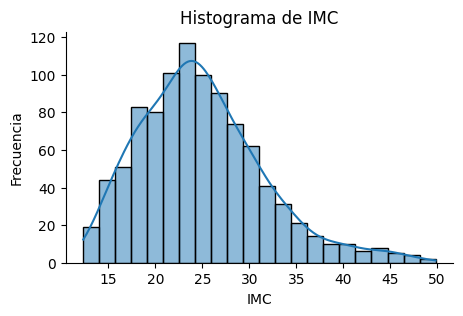

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

variables_numericas = [
    'Edad',
    'Peso (kg)',
    'Altura (m)',
    'BPM_Max',
    'Promedio_BPM',
    'Reposo_BPM',
    'Duracion_Sesionhrs',
    'Calorias_Quemadas',
    'Porcentaje_Grasa',
    'Consumo_Agua (litros)',
    'Frecuencia_Entrenamiento (dias/semanas)',
    'Nivel_Experiencia',
    'IMC'
]

for variable in variables_numericas:
    plt.figure(figsize=(5,3), dpi=100)
    sns.histplot(df[variable], kde=True)
    plt.xlabel(variable)
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de {variable}")
    plt.gca().spines[["top", "right"]].set_visible(False)
    plt.show()

In [71]:
df ["Genero"].unique()

array(['Male', 'Female'], dtype=object)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
Female   Male  82.2071   0.0 48.2331 116.181   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

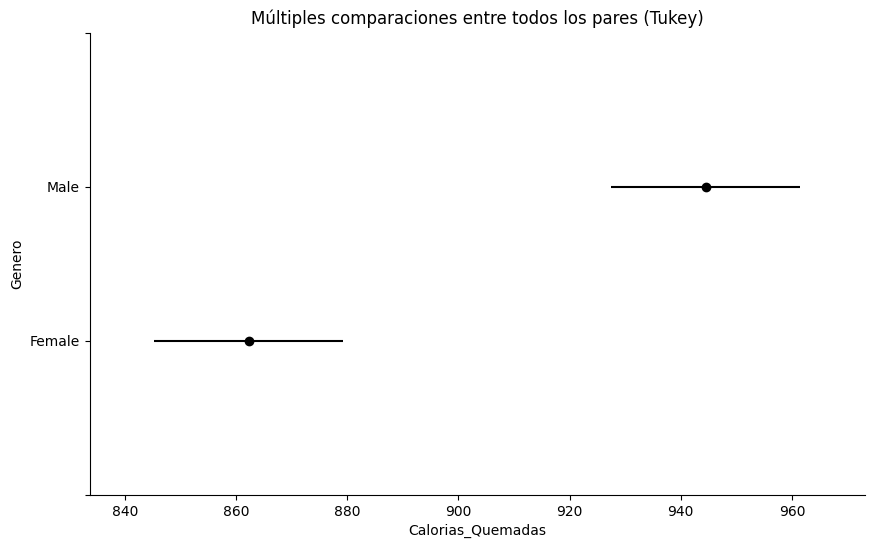

In [72]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Calorias_Quemadas'], groups=df['Genero'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Genero", xlabel="Calorias_Quemadas")
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")
#Test de Tukey\
# Es mejor cocerlos con Sal o T3


In [73]:
df["Genero"] = df["Genero"].map({
    "Female":  0,
    "Male": 1
})

df

,Edad,Genero,Peso (kg),Altura (m),BPM_Max,Promedio_BPM,Reposo_BPM,Duracion_Sesionhrs,Calorias_Quemadas,Tipo_Entrenamiento,Porcentaje_Grasa,Consumo_Agua (litros),Frecuencia_Entrenamiento (dias/semanas),Nivel_Experiencia,IMC
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,1,12.6,3.5,4,3,30.20
1,46,0,74.9,1.53,179,151,66,1.30,883.0,3,33.9,2.1,4,2,32.00
2,32,0,68.1,1.66,167,122,54,1.11,677.0,0,33.4,2.3,4,2,24.71
3,25,1,53.2,1.70,190,164,56,0.59,532.0,2,28.8,2.1,3,1,18.41
4,38,1,46.1,1.79,188,158,68,0.64,556.0,2,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,1,87.1,1.74,187,158,67,1.57,1364.0,2,10.0,3.5,4,3,28.77
969,25,1,66.6,1.61,184,166,56,1.38,1260.0,2,25.0,3.0,2,1,25.69
970,59,0,60.4,1.76,194,120,53,1.72,929.0,0,18.8,2.7,5,3,19.50
971,32,1,126.4,1.83,198,146,62,1.10,883.0,3,28.2,2.1,3,2,37.74


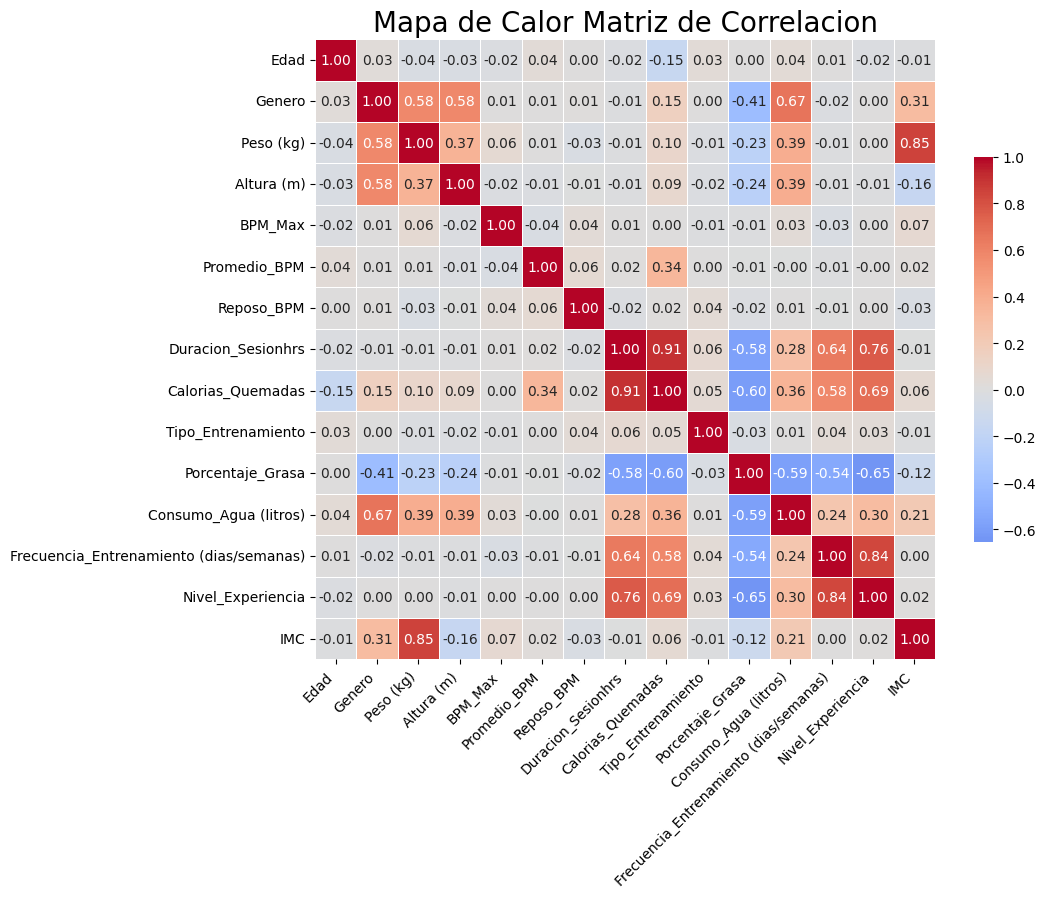

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
matriz_de_correlacion=df.corr()
plt.figure(figsize=(10,10),dpi=100)
sns.heatmap(matriz_de_correlacion, #lo que va a grafica
    annot=True,#se muestran los valores en las celdas
    fmt="0.2f", #0.2f significa 2 decimales
    cmap="coolwarm", #paleta de colroes
    square=True,#forzar cuadrado
    linewidths=0.5,#grosor de lineas
    cbar_kws={"shrink":0.5}, #tama;o de barra lateral
    center=0, #linea vertical central
)
plt.title("Mapa de Calor Matriz de Correlacion",fontsize=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

Coeficiente de determinación:  0.9304

Intervalo de confianza para b1 de  95%
 704.4376 < b1 <  730.8560

valor-p de Shapiro:  0.0000

valor_p de Breusch-Pagan:  0.0000



,df,sum_sq,mean_sq,F,PR(>F)
Duracion_Sesionhrs,1.0,5.958764e+07,5.958764e+07,11501.532839,0.000000e+00
Promedio_BPM,1.0,7.638999e+06,7.638999e+06,1474.470166,6.801658e-197
Residual,970.0,5.025418e+06,5.180844e+03,NaN,NaN


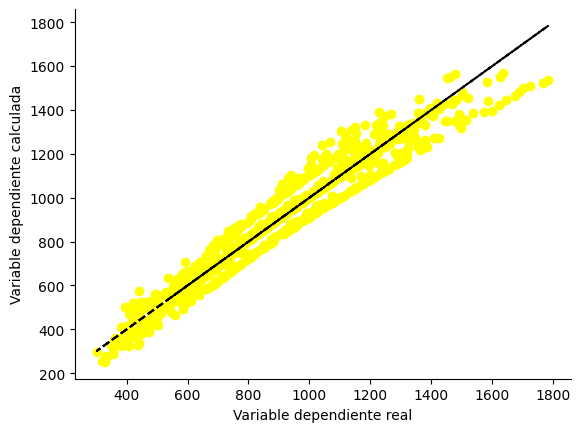

In [75]:
x = df[["Duracion_Sesionhrs", "Promedio_BPM"]]
y = df["Calorias_Quemadas"]

# # 2. Realice un diagrama de dispersión para estos datos.
# import matplotlib.pyplot as plt
# plt.figure(figsize = (16, 8), dpi = 100)
# plt.scatter(x, y, label = "Promedio final", color = 'red')
# plt.xlabel('Exámenes cortos') # nombrar eje x
# plt.ylabel('Promedio final') # nombrar eje y
# plt.gca().spines[["top","right"]].set_visible(False)

# 3. ¿Los datos soportan la suposición de linealidad?
# Sí

# 4. Calcule el coeficiente de correlación e interprete el resultado.
# from scipy.stats import pearsonr
# r, _ = pearsonr(x, y)
# print(f'Coeficiente de correlación: {r: 0.4f}\n')

# 6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de
# dispersión.
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()

yc = modelo.predict(x_constante)
plt.figure()
plt.plot(y, y, color = 'black', linestyle = '--')

# 5. Calcule el coeficiente de determinación e interprete el resultado.
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, yc)
print(f'Coeficiente de determinación: {r2: 0.4f}\n')

# 7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de
# regresión ajustada ( b1 )
nivel_de_confianza = 0.95
intervalo_de_confianza = modelo.conf_int(alpha = 1 - nivel_de_confianza)
intervalo_de_confianza_b1 = intervalo_de_confianza.iloc[1]
print(f'Intervalo de confianza para b1 de {nivel_de_confianza: 0.0%}')
print(f'{intervalo_de_confianza_b1[0]: 0.4f} < b1 < {intervalo_de_confianza_b1[1]: 0.4f}\n')

# 8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente,
# ¿Parece que se verifican los supuestos?
residuales = modelo.resid
plt.scatter(y, yc, color = 'yellow')
plt.xlabel('Variable dependiente real')
plt.ylabel('Variable dependiente calculada')
plt.gca().spines[['top', 'right']].set_visible(False)

# 9. Realice la prueba de Shapiro para los residuales y comente el resultado.
from scipy.stats import shapiro
_, valor_p_sh = shapiro(residuales)
print(f'valor-p de Shapiro: {valor_p_sh: 0.4f}\n')

# 10. Realice la prueba de Brausch-Pagan para los residuales y comente el
# resultado.
from statsmodels.stats.api import het_breuschpagan
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor_p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

# 11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de
# regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?
#print(f'para x1 = 0.5, x2 =3, x3=34, y = {modelo.predict([1, 0.5, 3, 34])}')
#print(f'para x1 = 1.5, x2 =2, x3=50, y = {modelo.predict([1, 1.5, 2, 50])}')
#print(f'para x1 = 2.5, x2 =4, x3=40, y = {modelo.predict([1, 2.0, 4, 40])}\n')
# print(f'para x = 72, y = {modelo.get_prediction([1, 0.5]).summary_frame()}')

# 12. Realice una tabla ANOVA e interprete el resultado.
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('Calorias_Quemadas ~ Duracion_Sesionhrs + Promedio_BPM', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova